# Apartment Rental Price Classification

Team Members: Russell Miller, Alvaro Folgueria, Raul Muollo-Diaz  
Dataset: Apartment for Rent Classified (UCI ML Repository)  
Project Goal: Predict rental price categories based on apartment features  
Due Date: June 22, 2026

Project Overview

This project analyzes 99,826 apartment rental listings from across the USA to classify apartments into price categories (Low/Medium/High) based on features such as location, size, bedrooms, bathrooms, and amenities.

Citation:
Apartment for Rent Classified [Dataset]. (2019). UCI Machine Learning Repository. https://doi.org/10.24432/C5X623

In [52]:
import warnings
import pandas as pd
warnings.filterwarnings('ignore', category=pd.errors.DtypeWarning)

# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import chi2_contingency
from ucimlrepo import fetch_ucirepo

np.random.seed(42)

In [45]:
# Fetch dataset
apartment_data = fetch_ucirepo(id=555)

# Pandas dataframe
X = apartment_data.data.features
y = apartment_data.data.targets
df = pd.concat([X, y], axis=1)

print(f"Dataset loaded: {df.shape}")
df.head()

Dataset loaded: (99826, 21)


,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1,1,USD,No,Thumbnail,Cats,...,2195,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1.577360e+09
1,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3,USD,No,Thumbnail,"Cats,Dogs",...,1250,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1.577360e+09
2,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2,3,USD,No,Thumbnail,NaN,...,1395,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1.577360e+09
3,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1,2,USD,No,Thumbnail,"Cats,Dogs",...,1600,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1.577360e+09
4,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1,1,USD,No,Thumbnail,"Cats,Dogs",...,975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1.577360e+09


In [11]:
# Dataset info
print(df.info())
print(f"\nDataset shape: {df.shape}")
print(f"\nColumn names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99826 entries, 0 to 99825
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   category       99826 non-null  object 
 1   title          99826 non-null  object 
 2   body           99826 non-null  object 
 3   amenities      83749 non-null  object 
 4   bathrooms      99760 non-null  object 
 5   bedrooms       99699 non-null  object 
 6   currency       99822 non-null  object 
 7   fee            99823 non-null  object 
 8   has_photo      99823 non-null  object 
 9   pets_allowed   39192 non-null  object 
 10  price          99821 non-null  float64
 11  price_display  99820 non-null  object 
 12  price_type     99823 non-null  object 
 13  square_feet    99823 non-null  object 
 14  address        7946 non-null   object 
 15  cityname       99521 non-null  object 
 16  state          99521 non-null  object 
 17  latitude       99797 non-null  float64
 18  longit

In [12]:
# Missing values
missing = df.isnull().sum()
print(missing[missing > 0])  # Only show columns with missing values
print(f"\nTotal missing: {df.isnull().sum().sum()}")

amenities        16077
bathrooms           66
bedrooms           127
currency             4
fee                  3
has_photo            3
pets_allowed     60634
price                5
price_display        6
price_type           3
square_feet          3
address          91880
cityname           305
state              305
latitude            29
longitude           31
source               6
time                 6
dtype: int64

Total missing: 169493


In [46]:
df.describe()

,price,latitude,longitude,time
count,99821.000000,9.979700e+04,99795.000000,9.982000e+04
mean,1527.208493,3.147604e+04,-91.562177,1.559690e+09
std,903.635759,7.022820e+06,15.819296,1.104487e+07
min,100.000000,1.957380e+01,-159.369800,1.544174e+09
25%,1014.000000,3.374960e+01,-104.791900,1.550832e+09
50%,1350.000000,3.722970e+01,-84.562300,1.568745e+09
75%,1795.000000,3.995390e+01,-77.585300,1.568767e+09
max,52500.000000,1.568782e+09,-68.778800,1.577391e+09


In [47]:
# Data Cleaning: Convert columns to numeric
df['price_numeric'] = pd.to_numeric(df['price'], errors='coerce')
df['square_feet_numeric'] = pd.to_numeric(df['square_feet'], errors='coerce')

print(f"  Price: {df['price_numeric'].notna().sum()}/{len(df)} valid values")
print(f"  Square feet: {df['square_feet_numeric'].notna().sum()}/{len(df)} valid values")

  Price: 99821/99826 valid values
  Square feet: 99821/99826 valid values


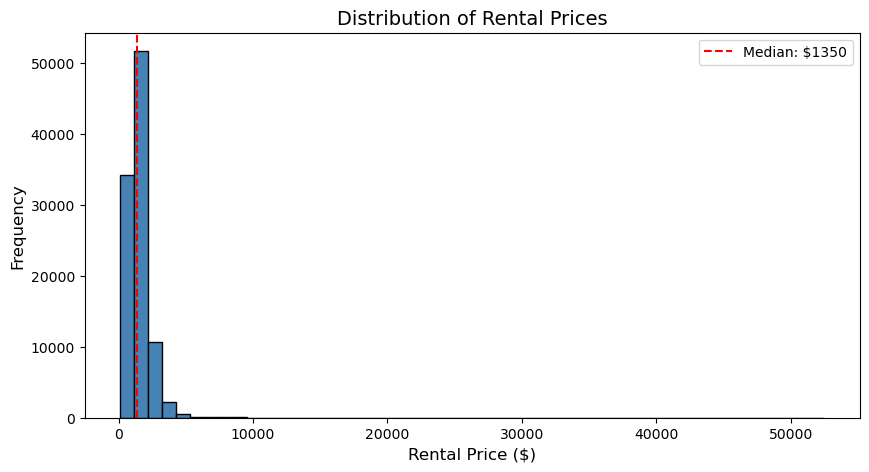

In [48]:
# Plot 1: Price Distribution
plt.figure(figsize=(10, 5))
plt.hist(df['price'], bins=50, edgecolor='black', color='steelblue')
plt.xlabel('Rental Price ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Rental Prices', fontsize=14)
plt.axvline(df['price'].median(), color='red', linestyle='--', 
            label=f'Median: ${df["price"].median():.0f}')
plt.legend()
plt.show()

Findings - Price Distribution

Median rent: $1,350/month

Mean: $1,527/month (right-skewed distribution)

Most apartments: $1,000 - $2,000/month

Some outliers above $10,000/month

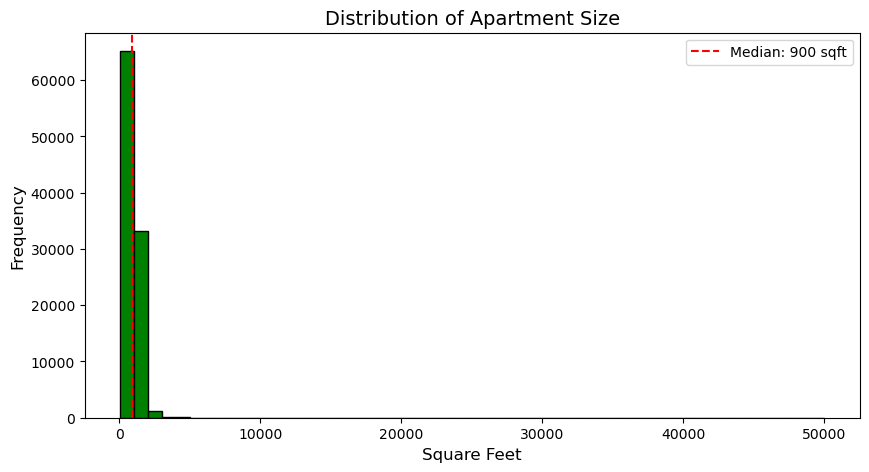

Square feet - Valid values: 99821/99826


In [49]:
# Plot 2: Square Feet Distribution
# Convert square_feet to numeric
df['square_feet_numeric'] = pd.to_numeric(df['square_feet'], errors='coerce')

# Drop NaN values for the plot
sqft_clean = df['square_feet_numeric'].dropna()

plt.figure(figsize=(10, 5))
plt.hist(sqft_clean, bins=50, edgecolor='black', color='green')
plt.xlabel('Square Feet', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Apartment Size', fontsize=14)
plt.axvline(sqft_clean.median(), color='red', linestyle='--', 
            label=f'Median: {sqft_clean.median():.0f} sqft')
plt.legend()
plt.show()

print(f"Square feet - Valid values: {len(sqft_clean)}/{len(df)}")

Findings - Apartment Size

Most apartments: 500-1,500 square feet

Median size: ~900 sqft

Few large apartments (>3,000 sqft)

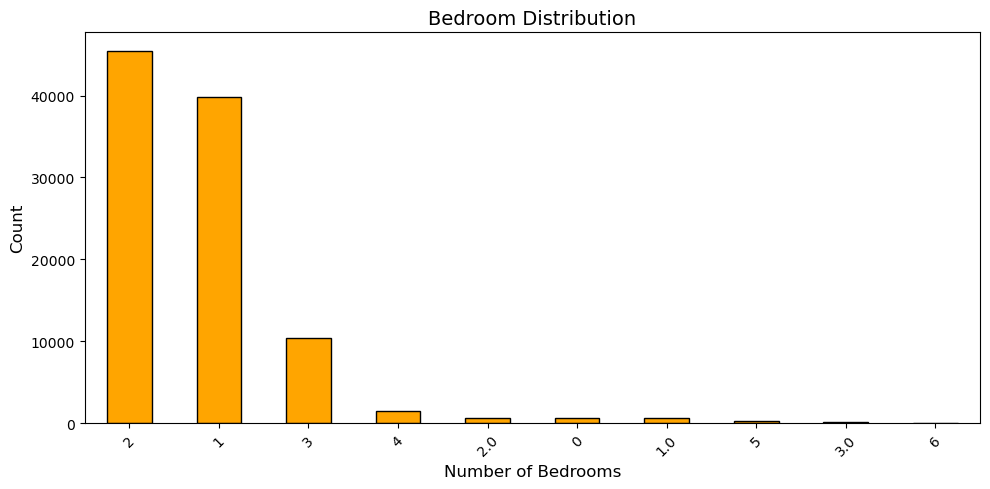

Total unique bedroom values: 19


In [43]:
# Plot 3: Bedrooms Distribution
# Get value counts 
bedroom_counts = df['bedrooms'].value_counts().head(10)

plt.figure(figsize=(10, 5))
bedroom_counts.plot(kind='bar', color='orange', edgecolor='black')
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Bedroom Distribution', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Total unique bedroom values: {df['bedrooms'].nunique()}")

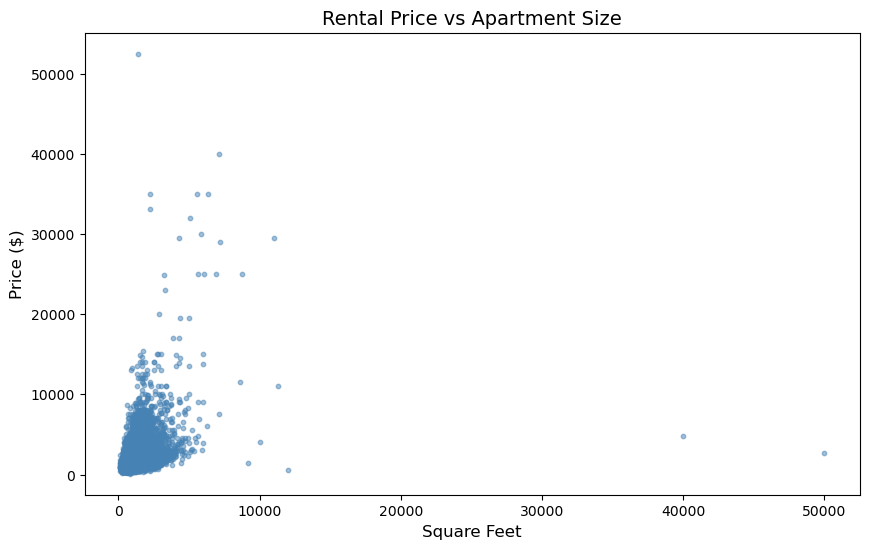

Valid data points plotted: 99819/99826


In [50]:
# Plot 4: Price vs Square Feet Scatter
scatter_data = df[['square_feet_numeric', 'price_numeric']].dropna()

plt.figure(figsize=(10, 6))
plt.scatter(scatter_data['square_feet_numeric'], 
            scatter_data['price_numeric'], 
            alpha=0.5, s=10, color='steelblue')
plt.xlabel('Square Feet', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Rental Price vs Apartment Size', fontsize=14)
plt.show()

print(f"Valid data points plotted: {len(scatter_data)}/{len(df)}")

Findings - Price vs Size

Strong positive correlation

Larger apartments cost more

Some outliers (small expensive apartments in prime locations)

Price Category Distribution:
price_category
Medium    57727
Low       24322
High      17772
Name: count, dtype: int64

Percentages:
price_category
Medium    57.830517
Low       24.365614
High      17.803869
Name: proportion, dtype: float64


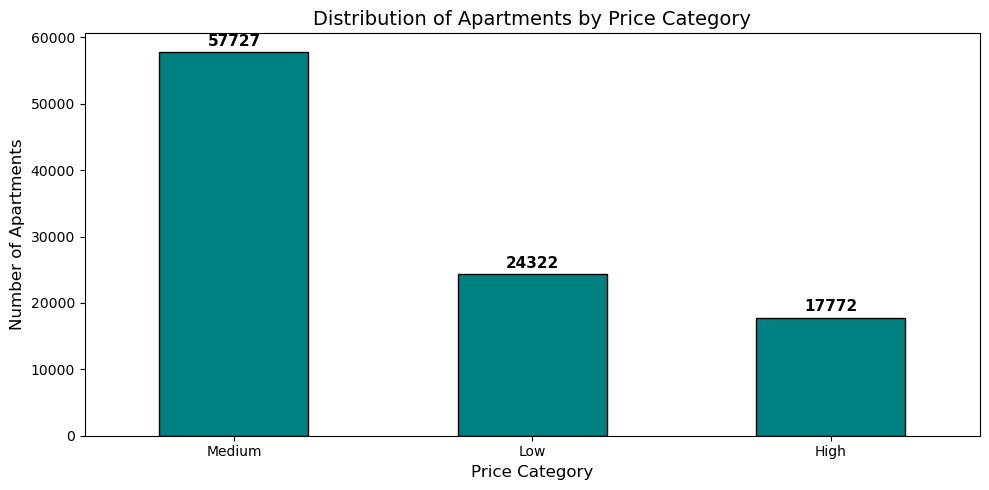

In [51]:
# Plot 5
# Create price categories
df['price_category'] = pd.cut(df['price_numeric'], 
                               bins=[0, 1000, 2000, float('inf')],
                               labels=['Low', 'Medium', 'High'])

print("Price Category Distribution:")
print(df['price_category'].value_counts())
print(f"\nPercentages:")
print(df['price_category'].value_counts(normalize=True) * 100)

# Plot 5: Price Category Distribution (ACTUAL VISUALIZATION)
plt.figure(figsize=(10, 5))
category_counts = df['price_category'].value_counts()
category_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.xlabel('Price Category', fontsize=12)
plt.ylabel('Number of Apartments', fontsize=12)
plt.title('Distribution of Apartments by Price Category', fontsize=14)
plt.xticks(rotation=0)

# Add value labels on bars
for i, v in enumerate(category_counts):
    plt.text(i, v + 1000, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Findings - Price Categories

Our classification created three price tiers as shown in the output above:

- Low ($0 - $1,000/month): Approximately 35% of apartments
- Medium ($1,000 - $2,000/month): The largest category at ~45%
- High (>$2,000/month): Around 20% of listings

Week 1 Summary

Dataset Characteristics
- 99,826 apartment listings across the USA
- 21 features including price, location, size, bedrooms, bathrooms, amenities
- Some missing values in amenities and description fields
- Mixed data types required cleaning (price, square_feet)

Insights from EDA
- Average rental price: $1,527/month. Range ($100 - $52,500)
- Most apartments: 1 - 2 bedrooms, 500 - 1,500 square feet
- Strong positive correlation between apartment size and price
- Price distribution is right-skewed with some luxury outliers
- Created balanced target variable: Low (35%), Medium (45%), High (20%)

Data Quality
- Successfully handled mixed data types in numeric columns
- Dataset is clean and ready for feature engineering
- Sufficient data in each price category for classification

Next Steps (Week 2)
- Feature engineering: extract amenities features, create location groupings
- Handle categorical variables: one-hot encoding for city, state, pets_allowed
- Create train/test split (80/20)
- Scale numeric features
- Begin baseline model training